In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly as py
import seaborn as sns
from pandasql import sqldf

In [127]:
df = pd.read_csv(
    "/home/g03-s2025/Desktop/SquashCoachingCopilot/squashcopilot/pipeline/outputs/video-3/video-3_analysis.csv"
)

In [44]:
pysqldf = lambda q: sqldf(q, globals())

### DF Manipulation


Adding ball speed + player id of the person who made the hit


In [131]:
import numpy as np


# Initialize speed column with NaNs
df["ball_speed"] = np.nan

# Filter wall hits
wall_hits = df[df["is_wall_hit"] == True]

for idx, wall_row in wall_hits.iterrows():
    # Get rally ID of this wall hit
    rally_id = wall_row["rally_id"]

    # Find the corresponding racket hit in same rally that happened before this wall hit
    racket_hit = (
        df[
            (df["rally_id"] == rally_id)
            & (df["is_racket_hit"] == True)
            & (df["timestamp"] < wall_row["timestamp"])
        ]
        .sort_values("timestamp")
        .iloc[-1]
    )  # take the latest one before wall hit

    # Get racket hit player
    player_id = racket_hit["racket_hit_player_id"]

    # Get player coordinates at racket hit
    if player_id == 1:
        x_racket = racket_hit["player_1_x_meter"]
        y_racket = racket_hit["player_1_y_meter"]
    else:
        x_racket = racket_hit["player_2_x_meter"]
        y_racket = racket_hit["player_2_y_meter"]

    # Wall hit coordinates
    x_wall = wall_row["wall_hit_x_meter"]
    y_wall = wall_row["wall_hit_y_meter"]

    # Euclidean distance
    distance = np.sqrt((x_wall - x_racket) ** 2 + (y_wall - y_racket) ** 2)

    # Time difference
    time_diff = wall_row["timestamp"] - racket_hit["timestamp"]

    # Ball speed (m/s)
    speed = distance / time_diff

    # Store speed in the wall hit row
    df.at[idx, "ball_speed"] = speed
    df.at[idx, "wall_hit_player_id"] = player_id

adding player quadrant


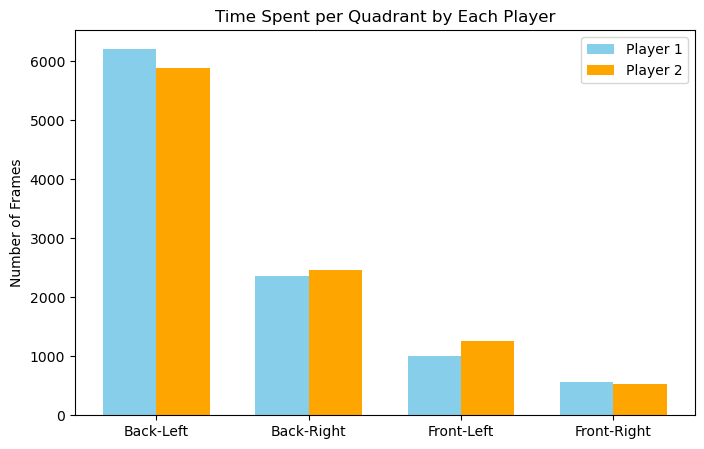

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fixed squash court boundaries
x_cut = 3.2
y_cut = 5.44


# Function to assign quadrant
def assign_quadrant(x, y):
    if x <= x_cut and y <= y_cut:
        return "Front-Left"
    elif x > x_cut and y <= y_cut:
        return "Front-Right"
    elif x <= x_cut and y > y_cut:
        return "Back-Left"
    else:
        return "Back-Right"


# Assign quadrants to each player
df["player_1_quadrant"] = df.apply(
    lambda row: assign_quadrant(row["player_1_x_meter"], row["player_1_y_meter"]),
    axis=1,
)
df["player_2_quadrant"] = df.apply(
    lambda row: assign_quadrant(row["player_2_x_meter"], row["player_2_y_meter"]),
    axis=1,
)

# Count frames per quadrant
quadrants = ["Back-Left", "Back-Right", "Front-Left", "Front-Right"]
p1_counts = [df["player_1_quadrant"].value_counts().get(q, 0) for q in quadrants]
p2_counts = [df["player_2_quadrant"].value_counts().get(q, 0) for q in quadrants]

# Plot side-by-side bar chart
x = np.arange(len(quadrants))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, p1_counts, width, label="Player 1", color="skyblue")
plt.bar(x + width / 2, p2_counts, width, label="Player 2", color="orange")
plt.xticks(x, quadrants)
plt.ylabel("Number of Frames")
plt.title("Time Spent per Quadrant by Each Player")
plt.legend()
plt.show()

### SQL Queries


#### % of Forehand / Backhand


In [6]:
# find total number of forehands for player 1

p1_forehand_count = (
    (df["stroke_type"] == "forehand") & (df["racket_hit_player_id"] == 1)
).sum()

# find total number of forehands for player 2

p1_backhand_count = (
    (df["stroke_type"] == "backhand") & (df["racket_hit_player_id"] == 1)
).sum()

p2_forehand_count = (
    (df["stroke_type"] == "forehand") & (df["racket_hit_player_id"] == 2)
).sum()

# find total number of forehands for player 2

p2_backhand_count = (
    (df["stroke_type"] == "backhand") & (df["racket_hit_player_id"] == 2)
).sum()

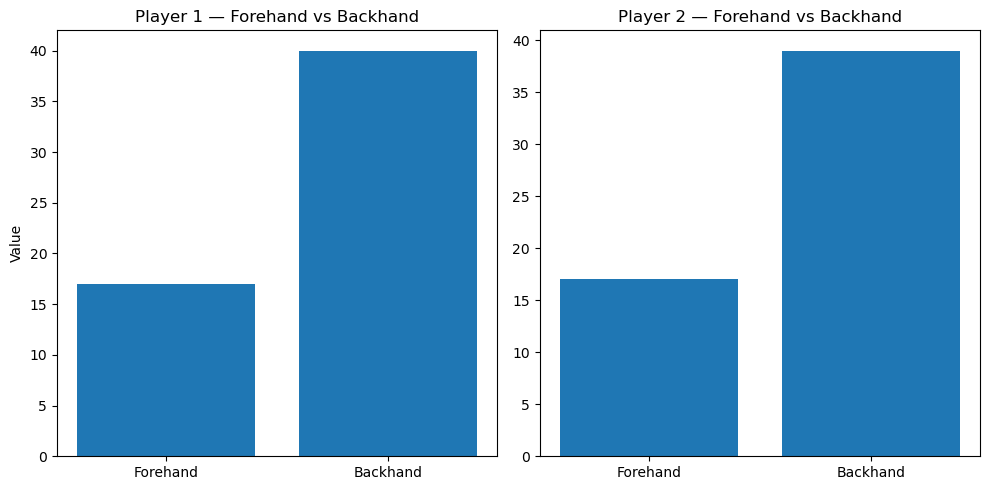

In [8]:
# make 2 subplots each as a bar grah between the player's forehand vs backhand per player

# Create figure with 2 subplots side-by-side
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# --- Player 1 subplot ---
axs[0].bar(["Forehand", "Backhand"], [p1_forehand_count, p1_backhand_count])
axs[0].set_title("Player 1 — Forehand vs Backhand")
axs[0].set_ylabel("Value")

# --- Player 2 subplot ---
axs[1].bar(["Forehand", "Backhand"], [p2_forehand_count, p2_backhand_count])
axs[1].set_title("Player 2 — Forehand vs Backhand")

plt.tight_layout()
plt.show()

In [ ]:
rally_id = None
player_id = None
start_time = None
end_time = None

stroke_type_query = """
SELECT
  COUNT( case when stroke_type = 'forehand' and racket_hit_player_id = 1 then 1 end) AS p1_forehand_count
  , COUNT( case when stroke_type = 'backhand' and racket_hit_player_id = 1 then 1 end) AS p1_backhand_count
  , COUNT( case when stroke_type = 'forehand' and racket_hit_player_id = 2 then 1 end) AS p2_forehand_count
  , COUNT( case when stroke_type = 'backhand' and racket_hit_player_id = 2 then 1 end) AS p2_backhand_count
FROM df
"""
conditions = []

if rally_id is not None:
    conditions.append(f"rally_id = {rally_id}")
if player_id is not None:
    conditions.append(f"wall_hit_player_id = {player_id}")
if start_time is not None:
    conditions.append(f"timestamp >= '{start_time}'")
if end_time is not None:
    conditions.append(f"timestamp <= '{end_time}'")

# If we have optional conditions, join them with OR (or AND if needed)
if conditions:
    shot_type_query += " AND (" + " AND ".join(conditions) + ")"

stroke_type_result = pysqldf(stroke_type_query)
print(stroke_type_result)

   p1_forehand_count  p1_backhand_count  p2_forehand_count  p2_backhand_count
0                 17                 40                 17                 39


#### Game % of drives / drops / cross-courts / lobs


In [12]:
# find total number of forehands for player 1

p1_staight_drive_count = (
    (df["shot_type"] == "straight_drive") & (df["racket_hit_player_id"] == 1)
).sum()

# find total number of forehands for player 2

p1_cross_court_drive_count = (
    (df["shot_type"] == "cross_court_drive") & (df["racket_hit_player_id"] == 1)
).sum()

p1_straight_drop_count = (
    (df["shot_type"] == "straight_drop") & (df["racket_hit_player_id"] == 1)
).sum()


p1_cross_court_drop_count = (
    (df["shot_type"] == "cross_court_drop") & (df["racket_hit_player_id"] == 1)
).sum()

# player 2

p2_staight_drive_count = (
    (df["shot_type"] == "straight_drive") & (df["racket_hit_player_id"] == 2)
).sum()

# find total number of forehands for player 2

p2_cross_court_drive_count = (
    (df["shot_type"] == "cross_court_drive") & (df["racket_hit_player_id"] == 2)
).sum()

p2_straight_drop_count = (
    (df["shot_type"] == "straight_drop") & (df["racket_hit_player_id"] == 2)
).sum()


p2_cross_court_drop_count = (
    (df["shot_type"] == "cross_court_drop") & (df["racket_hit_player_id"] == 2)
).sum()

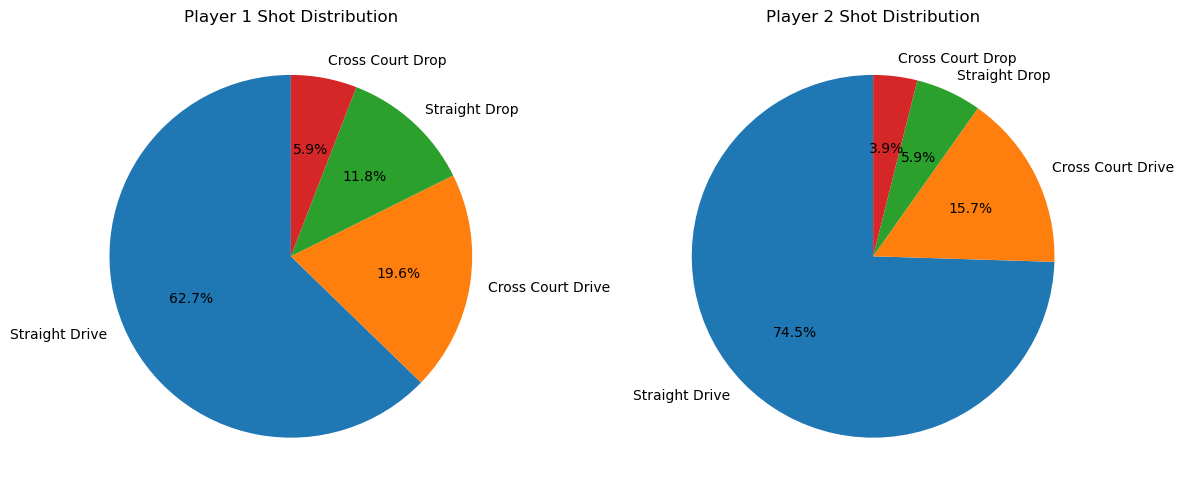

In [ ]:
import matplotlib.pyplot as plt

# Player 1 counts
p1_counts = [
    p1_staight_drive_count,
    p1_cross_court_drive_count,
    p1_straight_drop_count,
    p1_cross_court_drop_count,
]
p1_labels = ["Straight Drive", "Cross Court Drive", "Straight Drop", "Cross Court Drop"]

# Player 2 counts
p2_counts = [
    p2_staight_drive_count,
    p2_cross_court_drive_count,
    p2_straight_drop_count,
    p2_cross_court_drop_count,
]
p2_labels = ["Straight Drive", "Cross Court Drive", "Straight Drop", "Cross Court Drop"]

# Create side-by-side pie charts
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Player 1 pie chart
axs[0].pie(p1_counts, labels=p1_labels, autopct="%1.1f%%", startangle=90)
axs[0].set_title("Player 1 Shot Distribution")

# Player 2 pie chart
axs[1].pie(p2_counts, labels=p2_labels, autopct="%1.1f%%", startangle=90)
axs[1].set_title("Player 2 Shot Distribution")

plt.tight_layout()
plt.show()

In [ ]:
# SQL Query

rally_id = None
player_id = None
start_time = None
end_time = None
shot_type_query = """
SELECT
  COUNT( case when shot_type = 'straight_drive' and racket_hit_player_id = 1 then 1 end) AS p1_staight_drive_count
  , COUNT( case when shot_type = 'cross_court_drive' and racket_hit_player_id = 1 then 1 end) AS p1_cross_court_drive_count
  , COUNT( case when shot_type = 'straight_drop' and racket_hit_player_id = 1 then 1 end) AS p1_straight_drop_count
  , COUNT( case when shot_type = 'cross_court_drop' and racket_hit_player_id = 1 then 1 end) AS p1_cross_court_drop_count
  , COUNT( case when shot_type = 'straight_drive' and racket_hit_player_id = 2 then 1 end) AS p2_staight_drive_count
  , COUNT( case when shot_type = 'cross_court_drive' and racket_hit_player_id = 2 then 1 end) AS p2_cross_court_drive_count
  , COUNT( case when shot_type = 'straight_drop' and racket_hit_player_id = 2 then 1 end) AS p2_straight_drop_count
  , COUNT( case when shot_type = 'cross_court_drop' and racket_hit_player_id = 2 then 1 end) AS p2_cross_court_drop_count
FROM df
"""

conditions = []

if rally_id is not None:
    conditions.append(f"rally_id = {rally_id}")
if player_id is not None:
    conditions.append(f"wall_hit_player_id = {player_id}")
if start_time is not None:
    conditions.append(f"timestamp >= '{start_time}'")
if end_time is not None:
    conditions.append(f"timestamp <= '{end_time}'")

# If we have optional conditions, join them with OR (or AND if needed)
if conditions:
    shot_type_query += " AND (" + " AND ".join(conditions) + ")"

shot_type_result = pysqldf(shot_type_query)
print(shot_type_result)

   p1_staight_drive_count  p1_cross_court_drive_count  p1_straight_drop_count  \
0                      32                          10                       6   

   p1_cross_court_drop_count  p2_staight_drive_count  \
0                          3                      38   

   p2_cross_court_drive_count  p2_straight_drop_count  \
0                           8                       3   

   p2_cross_court_drop_count  
0                          2  


#### Approximate Ball speed (Power Proxy)


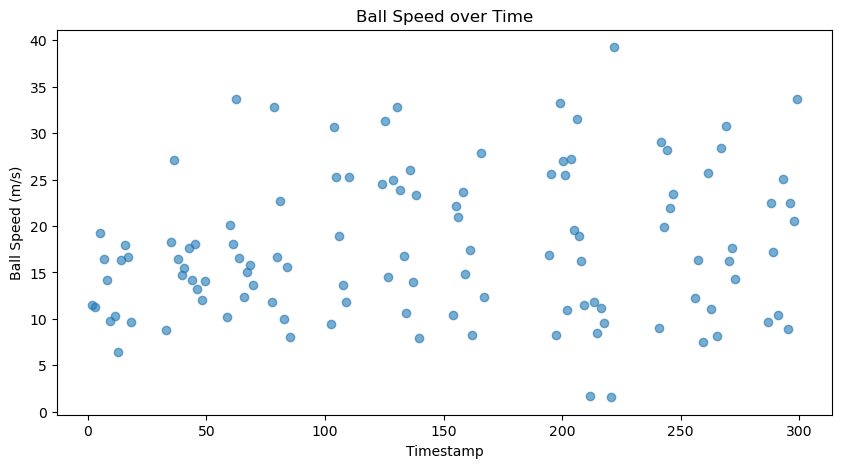

In [29]:
plt.figure(figsize=(10, 5))
plt.scatter(df_speed["timestamp"], df_speed["ball_speed"], alpha=0.6)
plt.xlabel("Timestamp")
plt.ylabel("Ball Speed (m/s)")
plt.title("Ball Speed over Time")
plt.show()

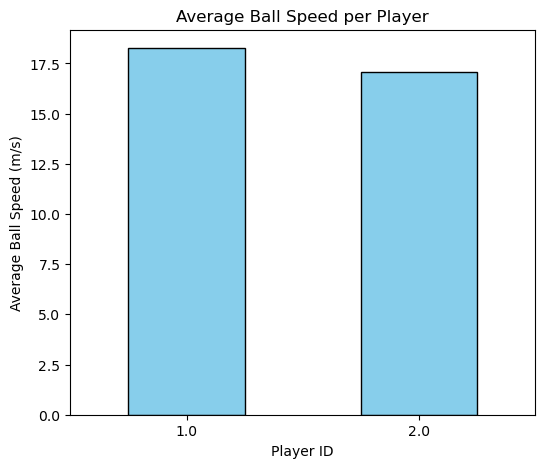

In [ ]:
import matplotlib.pyplot as plt

# Compute average ball speed per player
avg_speed = df_speed.groupby("wall_hit_player_id")["ball_speed"].mean()

# Plot bar chart
plt.figure(figsize=(6, 5))
avg_speed.plot(kind="bar", color="skyblue", edgecolor="black")
plt.xlabel("Player ID")
plt.ylabel("Average Ball Speed (m/s)")
plt.title("Average Ball Speed per Player")
plt.xticks(rotation=0)
plt.show()

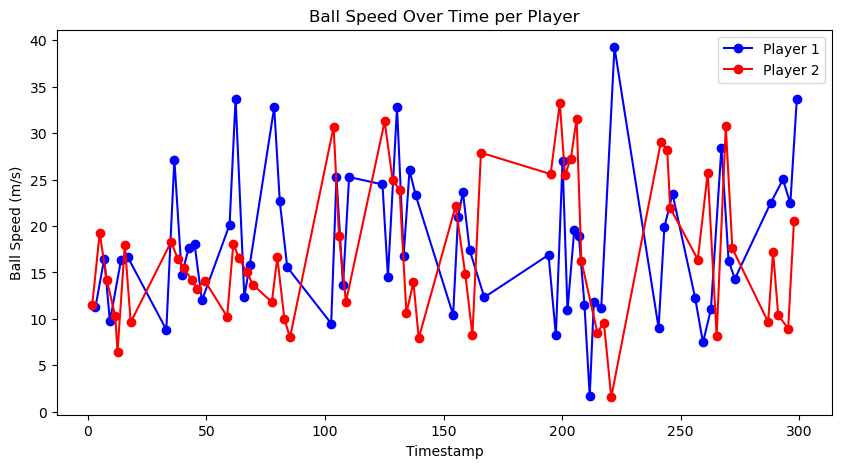

In [ ]:
import matplotlib.pyplot as plt

# Filter only rows with ball_speed
df_hits = df.dropna(subset=["ball_speed"])

# Separate data per player
player1 = df_hits[df_hits["wall_hit_player_id"] == 1]
player2 = df_hits[df_hits["wall_hit_player_id"] == 2]

plt.figure(figsize=(10, 5))

# Plot player 1
plt.plot(
    player1["timestamp"],
    player1["ball_speed"],
    color="blue",
    label="Player 1",
    marker="o",
    linestyle="-",
)

# Plot player 2
plt.plot(
    player2["timestamp"],
    player2["ball_speed"],
    color="red",
    label="Player 2",
    marker="o",
    linestyle="-",
)

plt.xlabel("Timestamp")
plt.ylabel("Ball Speed (m/s)")
plt.title("Ball Speed Over Time per Player")
plt.legend()
plt.show()

In [122]:
# SQL Query

rally_id = 0  # or 0
player_id = None  # or None
start_time = 1
end_time = 5

ball_speed_query = """
SELECT timestamp, ball_speed, wall_hit_player_id as player_id
FROM df
where ball_speed is not null
"""
# Build list of conditions
conditions = []

if rally_id is not None:
    conditions.append(f"rally_id = {rally_id}")
if player_id is not None:
    conditions.append(f"wall_hit_player_id = {player_id}")
if start_time is not None:
    conditions.append(f"timestamp >= '{start_time}'")
if end_time is not None:
    conditions.append(f"timestamp <= '{end_time}'")

# If we have optional conditions, join them with OR (or AND if needed)
if conditions:
    ball_speed_query += " AND (" + " AND ".join(conditions) + ")"

# Print the final query for debugging
print("Final SQL query:\n", ball_speed_query)

print()

ball_speed_result = pysqldf(ball_speed_query)
print(ball_speed_result)

Final SQL query:
 
SELECT timestamp, ball_speed, wall_hit_player_id as player_id
FROM df
where ball_speed is not null
 AND (rally_id = 0 AND timestamp >= '1' AND timestamp <= '5')

   timestamp  ball_speed  player_id
0   1.866667   11.500998        2.0
1   3.200000   11.249544        1.0
2   5.000000   19.264637        2.0


#### Opponent Rhythm Disruption


#### Game Heatmap


In [ ]:
player_heatmap_query = """
SELECT 
  player_1_x_meter,
  player_1_y_meter,
  player_2_x_meter,
  player_2_y_meter
FROM df
"""

if rally_id is not None:
    player_heatmap_query += f" WHERE rally_id = {rally_id}"

player_heatmap_result = pysqldf(player_heatmap_query)
print(player_heatmap_result)

       player_1_x_meter  player_1_y_meter  player_2_x_meter  player_2_y_meter
0              2.011459          7.675627          5.885906          6.113835
1              2.011459          7.675627          5.885906          6.113835
2              2.011459          7.675627          5.885906          6.113835
3              2.011459          7.675627          5.885906          6.113835
4              2.011459          7.675627          5.885906          6.113835
...                 ...               ...               ...               ...
10352          3.852708          6.742110          4.785708          7.720239
10353          3.831132          6.739552          4.808252          7.717013
10354          3.808543          6.736366          4.826225          7.714142
10355          3.789596          6.733300          4.838052          7.711968
10356          3.778768          6.731390          4.843661          7.710802

[10357 rows x 4 columns]


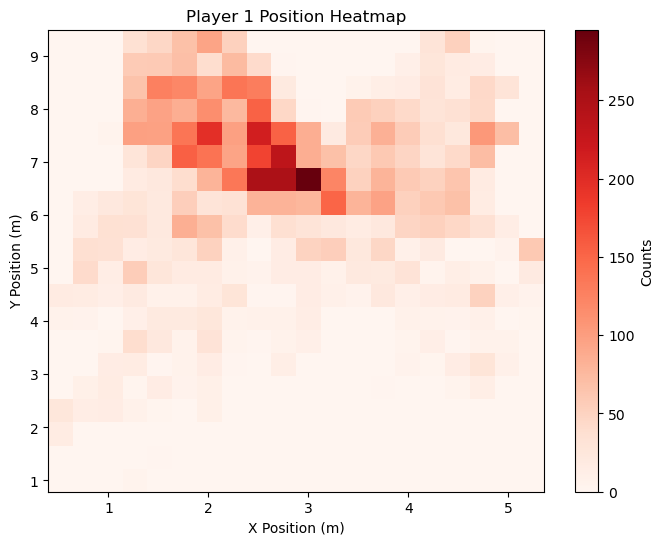

In [75]:
plt.figure(figsize=(8, 6))
plt.hist2d(
    player_heatmap_result["player_1_x_meter"],
    player_heatmap_result["player_1_y_meter"],
    bins=20,  # adjust resolution
    cmap="Reds",
)
plt.colorbar(label="Counts")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Player 1 Position Heatmap")
plt.show()

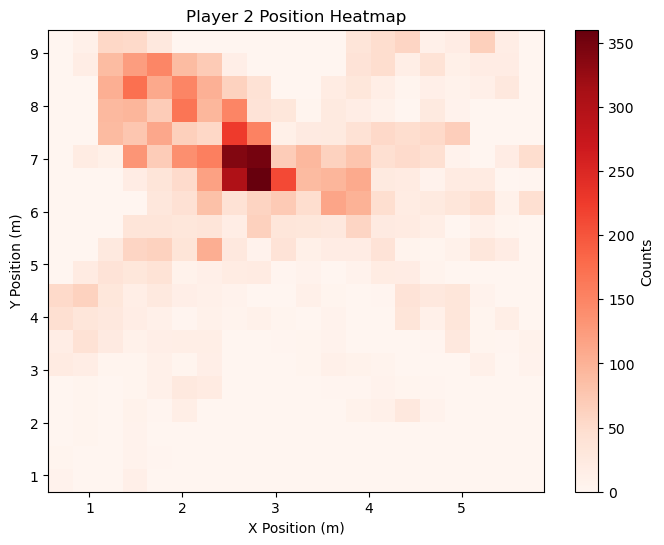

In [77]:
plt.figure(figsize=(8, 6))
plt.hist2d(
    player_heatmap_result["player_2_x_meter"],
    player_heatmap_result["player_2_y_meter"],
    bins=20,  # adjust resolution
    cmap="Reds",
)
plt.colorbar(label="Counts")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Player 2 Position Heatmap")
plt.show()

#### Shot Placement Heatmap


#### Shot Placement Effectiveness MOST IMPORTANT


#### Court distribution in front middle back


In [148]:
rally_id = None  # or 0
player_id = None  # or None
start_time = None
end_time = None

court_dist_query = """
SELECT 
player_1_quadrant,
player_2_quadrant
FROM df
"""


# Build list of conditions
conditions = []

if rally_id is not None:
    conditions.append(f"rally_id = {rally_id}")
if player_id is not None:
    conditions.append(f"wall_hit_player_id = {player_id}")
if start_time is not None:
    conditions.append(f"timestamp >= '{start_time}'")
if end_time is not None:
    conditions.append(f"timestamp <= '{end_time}'")

# If we have optional conditions, join them with OR (or AND if needed)
if conditions:
    court_dist_query += " where (" + " AND ".join(conditions) + ")"

# Print the final query for debugging
print("Final SQL query:\n", court_dist_query)

print()

wall_hit_heatmap_result = pysqldf(court_dist_query)
print(wall_hit_heatmap_result)

Final SQL query:
 
SELECT 
player_1_quadrant,
player_2_quadrant
FROM df


      player_1_quadrant player_2_quadrant
0             Back-Left        Back-Right
1             Back-Left        Back-Right
2             Back-Left        Back-Right
3             Back-Left        Back-Right
4             Back-Left        Back-Right
...                 ...               ...
10137        Back-Right        Back-Right
10138        Back-Right        Back-Right
10139        Back-Right        Back-Right
10140        Back-Right        Back-Right
10141        Back-Right        Back-Right

[10142 rows x 2 columns]


#### Average Rally Length + Plot


In [139]:
# Base query
avg_rally_length_query = """
SELECT 
    rally_id,
    MAX(timestamp) - MIN(timestamp) as rally_length,
    COUNT(CASE WHEN is_racket_hit THEN 1 END)  as stroke_count
FROM df
GROUP BY rally_id"""

print("Final SQL query:\n", avg_rally_length_query)

print()

avg_rally_length_result = pysqldf(avg_rally_length_query)
print(avg_rally_length_result)

Final SQL query:
 
SELECT 
    rally_id,
    MAX(timestamp) - MIN(timestamp) as rally_length,
    COUNT(CASE WHEN is_racket_hit THEN 1 END)  as stroke_count
FROM df
GROUP BY rally_id

    rally_id  rally_length  stroke_count
0          0     19.033333            12
1          1     17.650000            12
2          2     11.683333             9
3          3     10.083333             7
4          4     10.466667             7
5          5     16.950000            12
6          6     14.533333            10
7          7     29.450000            19
8          8      7.433333             6
9          9     17.850000            11
10        10     13.716667             9


#### Wall hit distribution (as is) - filter by player (lon w lon)


In [120]:
# Example variables
rally_id = 0  # or 0
player_id = None  # or None
start_time = 1
end_time = 5
# Base query
wall_hit_heatmap_query = """
SELECT 
    wall_hit_player_id,
    rally_id,
    wall_hit_x_meter,
    wall_hit_y_meter
FROM df
WHERE is_wall_hit = TRUE
"""

# Build list of conditions
conditions = []

if rally_id is not None:
    conditions.append(f"rally_id = {rally_id}")
if player_id is not None:
    conditions.append(f"wall_hit_player_id = {player_id}")
if start_time is not None:
    conditions.append(f"timestamp >= '{start_time}'")
if end_time is not None:
    conditions.append(f"timestamp <= '{end_time}'")

# If we have optional conditions, join them with OR (or AND if needed)
if conditions:
    wall_hit_heatmap_query += " AND (" + " AND ".join(conditions) + ")"

# Print the final query for debugging
print("Final SQL query:\n", wall_hit_heatmap_query)

print()

wall_hit_heatmap_result = pysqldf(wall_hit_heatmap_query)
print(wall_hit_heatmap_result)

Final SQL query:
 
SELECT 
    wall_hit_player_id,
    rally_id,
    wall_hit_x_meter,
    wall_hit_y_meter
FROM df
WHERE is_wall_hit = TRUE
 AND (rally_id = 0 AND timestamp >= '1' AND timestamp <= '5')

   wall_hit_player_id  rally_id  wall_hit_x_meter  wall_hit_y_meter
0                 2.0         0          1.244997          2.929987
1                 1.0         0          0.631000          3.447266
2                 2.0         0          0.281628          1.642160


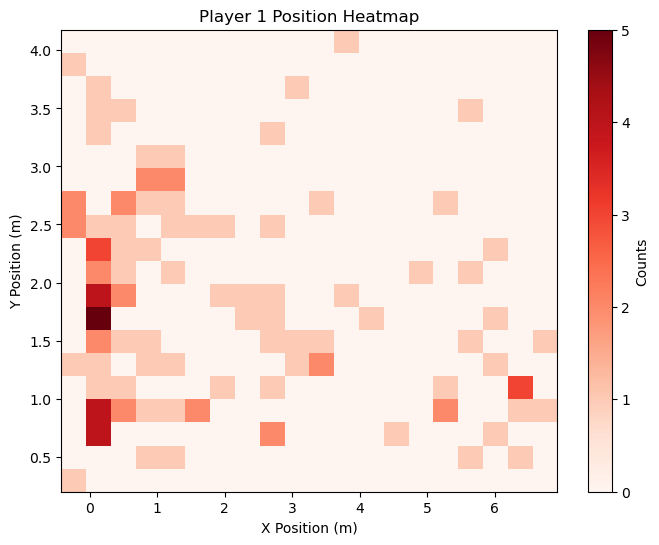

In [81]:
plt.figure(figsize=(8, 6))
plt.hist2d(
    wall_hit_heatmap_result["wall_hit_x_meter"],
    wall_hit_heatmap_result["wall_hit_y_meter"],
    bins=20,  # adjust resolution
    cmap="Reds",
)
plt.colorbar(label="Counts")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Player 1 Position Heatmap")
plt.show()